Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading annotations into memory...
Done (t=21.28s)
creating index...
index created!


100%|██████████| 36599/36599 [13:36<00:00, 44.83it/s]


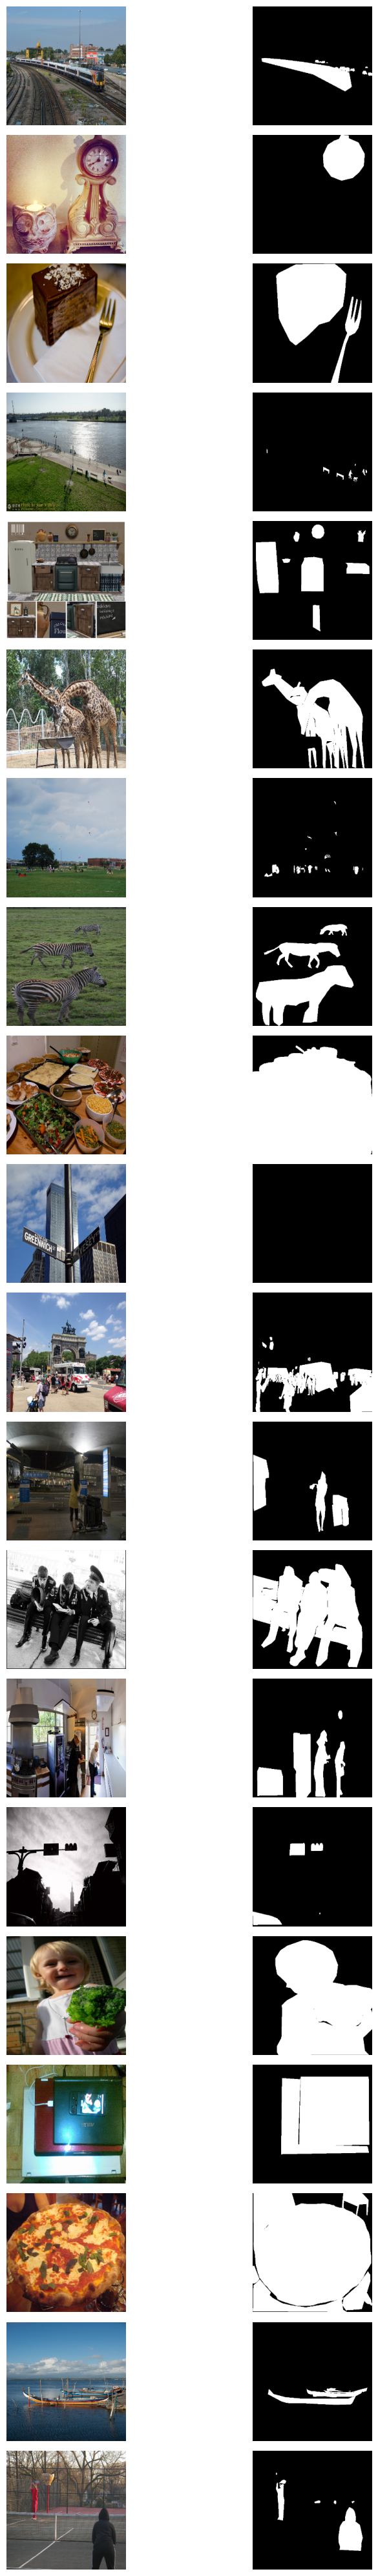

In [36]:
from google.colab import drive
drive.mount('/content/drive')

import os, urllib.request, zipfile, cv2, numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pycocotools.coco import COCO

BASE = "/content/drive/MyDrive/coco20k"
IMG_DIR = BASE + "/images"
MASK_DIR = BASE + "/masks"
os.makedirs(MASK_DIR, exist_ok=True)

ANN_DIR = "/content/annotations"
os.makedirs(ANN_DIR, exist_ok=True)
ANN_ZIP = "/content/instances_train2017.zip"
JSON_PATH = f"{ANN_DIR}/annotations/instances_train2017.json"

if not os.path.exists(JSON_PATH):
    url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
    urllib.request.urlretrieve(url, ANN_ZIP)
    with zipfile.ZipFile(ANN_ZIP, 'r') as z:
        z.extract("annotations/instances_train2017.json", ANN_DIR)

coco = COCO(JSON_PATH)

img_files = sorted(os.listdir(IMG_DIR))
saved = 0
skipped = 0

for f in tqdm(img_files):
    img_id = int(f.split(".")[0])
    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
    if len(anns) == 0:
        skipped += 1
        continue
    meta = coco.loadImgs(img_id)[0]
    h, w = meta["height"], meta["width"]
    mask = np.zeros((h, w), dtype=np.uint8)
    for ann in anns:
        m = coco.annToMask(ann)
        mask = np.logical_or(mask, m)
    out = os.path.join(MASK_DIR, f.replace(".jpg", ".png"))
    cv2.imwrite(out, (mask * 255).astype("uint8"))
    saved += 1

def load_img(p):
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (256, 256))

def load_mask(p):
    mask = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    return cv2.resize(mask, (256, 256))

files = img_files[:20]
plt.figure(figsize=(10, 40))
idx = 1

for f in files:
    img = load_img(os.path.join(IMG_DIR, f))
    mask = load_mask(os.path.join(MASK_DIR, f.replace(".jpg", ".png")))
    plt.subplot(20, 2, idx); idx += 1
    plt.imshow(img); plt.axis("off")
    plt.subplot(20, 2, idx); idx += 1
    plt.imshow(mask, cmap="gray"); plt.axis("off")

plt.tight_layout()
plt.savefig("/content/task2_final_20pairs.png")
plt.show()
